<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-I/blob/main/tibasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TIBASA – Simulación Monte Carlo

## Planteamiento del problema


La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

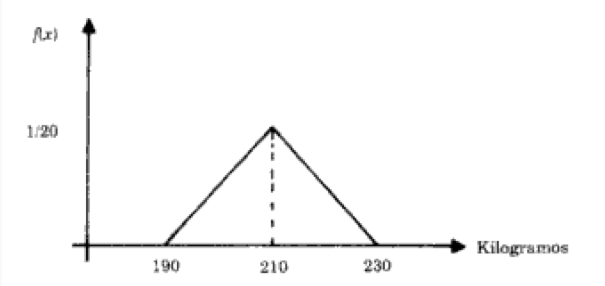Con parámetros:

$$
a = 190, \quad b = 230, \quad c = 210
$$


Si la capacidad del camión es 1 tonelada
$$
1000 \text{ kg}
$$


¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?. Es decir se desea estimar la probabilidad:

$$
P(S > 1000)
$$

donde:

$$
S = x_1 + x_2 + x_3 + x_4 + x_5
$$




## PASO 1. VARIABLES

Sea el peso de las tinas:

$$
x_1, x_2, x_3, x_4, x_5
$$

donde:

$$
x_i \sim \text{Triangular}(a,b,c)
$$

con:

$$
a = 190,\quad b = 230,\quad c = 210
$$

Necesitamos la suma y definimos:

$$
S = x_1 + x_2 + x_3 + x_4 + x_5
$$


$$
S = \sum_{i=1}^{5} x_i
$$

Evento de interés:

$$
S > 1000
$$


## ANÁLISIS TEÓRICO

La media de una variable triangular es:

$$
\mu = \frac{a + b + c}{3} = \frac{190 + 230 + 210}{3} = 210
$$

La varianza es:

$$
\sigma^2 = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18} = \frac{200}{3}
$$

Entonces:

$$
\sigma = \sqrt{\frac{200}{3}} \approx 8.16
$$

Para la suma de 5 tinas:

$$
\mu_S = 5(210) = 1050
$$

$$
\sigma_S^2 = 5 \cdot \frac{200}{3} = \frac{1000}{3}
$$

$$
\sigma_S = \sqrt{\frac{1000}{3}} \approx 18.26
$$

Por el Teorema Central del Límite:

$$
S \approx N(1050, (18.26)^2)
$$

Estandarizando:

$$
Z = \frac{1000 - 1050}{18.26} = -2.74
$$

Entonces:

$$
P(S > 1000) = P(Z > -2.74) \approx 0.997
$$


Este resultado se utiliza únicamente como referencia teórica para validar la simulación . Es decir analiticamente, la probabilidad de que la suma de los pesos de las suma de las 5 tinas es superior  1000 kg el 99.7% de las veces.

# SIMULACIÓN

In [1]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

###  PASO 1. VARIABLES

Se modelan las variables como:

$$
x_i \sim \text{triangular}(190,230,210)
$$




## PASO 4. DEFINIMOS EL MODELO

Se define una función que:

- Genera 5 tinas
- Calcula la suma
- Retorna el peso total

In [2]:
def tinas(a,b,c):
  lista = []
  for i in range(5):
    tina = r.triangular(a,b,c)
    lista.append(tina)
  s = sum(lista)
  return s

## PASO 5. DISEÑO DEL EXPERIMENTO

Cada simulación representa un día.

Definimos:

- Éxito si $S > 1000 $
- Fracaso si $S \leq 1000 $

In [3]:
a=190
b=230
c=210
tinas(a,b,c)

1033.7394424997806

## PASO 6. REPETIR \(n\) VECES

Se estima:

$$
\hat{p} = \frac{x}{n}
$$

Resultado:

$$
\hat{p} \approx 0.9975
$$

Interpretación:

Aproximadamente el **99.7% de las veces** se excede la capacidad.

In [4]:
def simulacion(n):
  contador = 0
  l = []
  for i in range(n):
    s = tinas(a,b,c)
    if s > 1000:
      contador += 1
    l.append(contador/(i+1))
  print(contador/n )
  return l

In [5]:
n=30000
M = simulacion(n)

0.9981


## PASO 7. GRÁFICA DE ESTABILIZACIÓN

La gráfica muestra cómo la probabilidad estimada converge conforme aumenta el número de simulaciones.

Esto es consistente con la **Ley de los Grandes Números**.

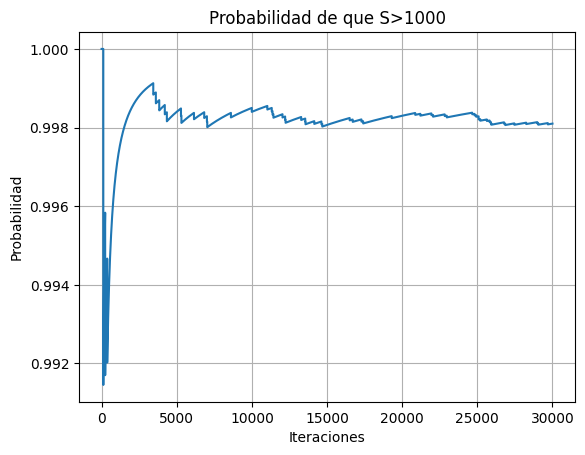

In [6]:
plt.plot(M)
plt.title("Probabilidad de que S>1000")
plt.xlabel("Iteraciones")
plt.ylabel("Probabilidad")
plt.grid()
plt.show()

##  PASO 9. MEDIA Y VARIANZA

Se calcula la media y desviación de la estimación.



In [7]:
np.mean(M)

np.float64(0.9981757414437569)

In [8]:
np.std(M)

np.float64(0.0006755503499063715)


## PASO 10. INTERVALO DE CONFIANZA

Cada simulación es un experimento Bernoulli:

- Éxito: $S > 1000 $
- Fracaso: $ S \leq 1000 $

Intervalo:

$$
\hat{p} \pm 1.96 \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$


La probabilidad de exceder la capacidad del camión es extremadamente alta (≈ 0.998).

Esto indica que el sistema opera en sobrecarga la mayor parte del tiempo.

Además, el resultado de la simulación coincide con el análisis teórico, lo cual valida el modelo.

In [10]:
p = M[-1]
error = 1.96 * np.sqrt(p * (1 - p) / n)
IC = (p - error, p + error)
IC

(np.float64(0.9976072129660797), np.float64(0.9985927870339203))

##  PASO EXTRA. HISTOGRAMA DEL PESO TOTAL

Se construye el histograma de la variable:

$$
S = x_1 + x_2 + x_3 + x_4 + x_5
$$

El objetivo es visualizar la distribución empírica de la suma de los pesos.

Por el Teorema Central del Límite, se espera que la distribución de $S$ tenga una forma aproximadamente normal.

Esto permite comparar:

- Resultado teórico (Normal)
- Resultado simulado (Monte Carlo)

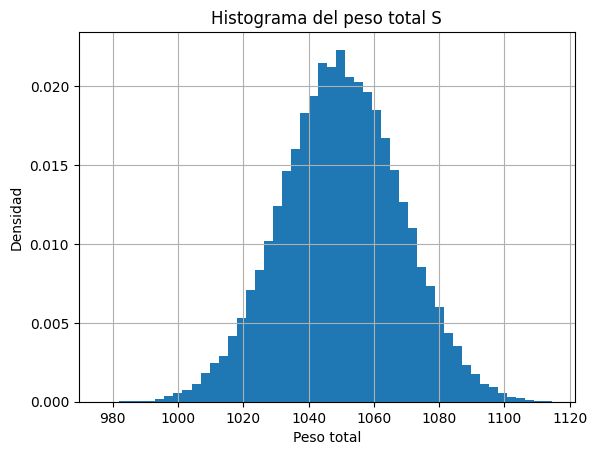

In [11]:
# Generamos muestras de S
S_vals = []

for i in range(n):
    S_vals.append(tinas(a,b,c))

# Histograma
plt.hist(S_vals, bins=50, density=True)

plt.title("Histograma del peso total S")
plt.xlabel("Peso total")
plt.ylabel("Densidad")
plt.grid()

plt.show()

Se modeló el peso de las tinas mediante una distribución triangular y se analizó la suma total usando el Teorema Central del Límite, obteniendo que:

$$
S \sim N(1050, (18.26)^2)
$$

A partir de esto, se calculó:

$$
P(S > 1000) \approx 0.997
$$

La simulación Monte Carlo confirmó este resultado, mostrando una alta concordancia con la teoría.

En consecuencia, se concluye que existe una probabilidad muy alta de que el camión exceda su capacidad, lo que indica un riesgo significativo de sobrecarga en las condiciones actuales.